## Controles de la Simulación


# El Problema de la Aguja de Buffon

## 📌 ¿Qué es el Problema de la Aguja de Buffon?

El **Problema de la Aguja de Buffon** es un famoso problema de probabilidad geométrica propuesto por el naturalista francés **Georges-Louis Leclerc, Conde de Buffon** en 1733. Es considerado uno de los primeros ejemplos de **método de Monte Carlo** en la historia.

## 🎯 El Problema Original

**Enunciado:** Se tienen líneas paralelas separadas por una distancia **D** y una aguja de longitud **L** (donde L ≤ D). Si se lanza la aguja aleatoriamente sobre las líneas, ¿cuál es la probabilidad de que la aguja cruce alguna de las líneas?

## 📐 Solución Matemática

La probabilidad teórica de que la aguja cruce una línea es:

$$
P = \frac{2L}{\pi D}
$$

Despejando para π:

$$
\pi = \frac{2L}{P \cdot D}
$$

Donde:
- **L** = longitud de la aguja
- **D** = distancia entre líneas
- **P** = probabilidad experimental (agujas que cruzan / total de agujas)

## 🔍 Demostración Matemática

### Caso 1: Aguja de longitud L ≤ D

Sea:
- **x** = distancia del centro de la aguja a la línea más cercana (0 ≤ x ≤ D/2)
- **θ** = ángulo de la aguja con las líneas (0 ≤ θ ≤ π/2)

La aguja cruza una línea si:

$$
x \leq \frac{L}{2} \sin\theta
$$

El área favorable en el espacio (x, θ) es:

$$
\int_0^{\pi/2} \int_0^{\frac{L}{2}\sin\theta} dx\, d\theta = \int_0^{\pi/2} \frac{L}{2}\sin\theta\, d\theta = \frac{L}{2}
$$

El área total es:

$$
\int_0^{\pi/2} \int_0^{D/2} dx\, d\theta = \frac{\pi D}{4}
$$

Por lo tanto, la probabilidad es:

$$
P = \frac{\frac{L}{2}}{\frac{\pi D}{4}} = \frac{2L}{\pi D}
$$

## 🎲 Simulación de Monte Carlo

En nuestra simulación:
- **D** = 1.0 (separación entre líneas)
- **L** = 0.8 (longitud de la aguja)
- **P** se estima experimentalmente

Cada vez que lanzamos agujas, estimamos π como:

$$
\pi_{estimado} = \frac{2 \times 0.8 \times N_{total}}{1 \times N_{cruzan}}
$$

## 📊 Interpretación de la Simulación

- **Agujas azules**: No cruzan líneas
- **Agujas rojas**: Cruzan al menos una línea
- A mayor número de agujas, mejor la estimación de π

## 💡 Aplicaciones e Importancia

1. **Métodos de Monte Carlo**: Precursor de técnicas computacionales modernas
2. **Integración numérica**: Estimación de áreas y volúmenes complejos
3. **Física estadística**: Modelado de sistemas aleatorios
4. **Gránulos de cálculo**: Ejemplo clásico de probabilidad geométrica

## 🚀 ¡Experimenta!

Usa los controles para:
1. **Lanzar agujas** y observar cómo cambia la estimación
2. **Ajustar el número** de agujas por lanzamiento
3. **Reiniciar** la simulación para comenzar de nuevo

**¡Observa cómo la estimación de π se acerca al valor real a medida que lanzas más agujas!**


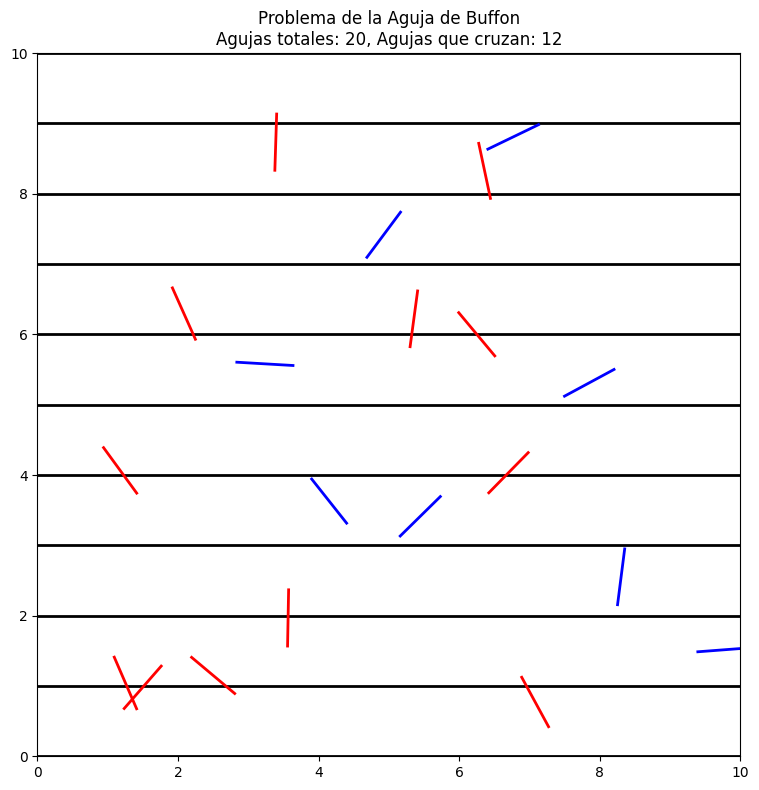


### Resultados de la Simulación:
- **Agujas totales**: 20
- **Agujas que cruzan**: 12
- **Probabilidad estimada**: 0.6000
- **π estimado**: 2.666667
- **π real**: 3.141593
- **Error**: 15.12%
            

<Figure size 640x480 with 0 Axes>


### Resultados de la Simulación:
- **Agujas totales**: 50
- **Agujas que cruzan**: 28
- **Probabilidad estimada**: 0.5600
- **π estimado**: 2.857143
- **π real**: 3.141593
- **Error**: 9.05%
            

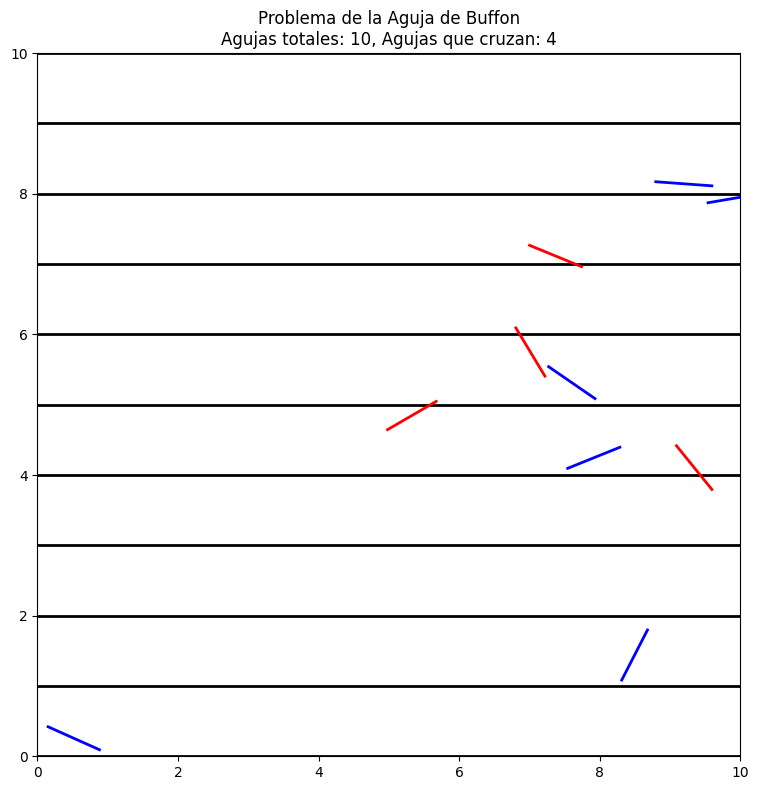


### Resultados de la Simulación:
- **Agujas totales**: 10
- **Agujas que cruzan**: 4
- **Probabilidad estimada**: 0.4000
- **π estimado**: 4.000000
- **π real**: 3.141593
- **Error**: 27.32%
            

<Figure size 640x480 with 0 Axes>


### Resultados de la Simulación:
- **Agujas totales**: 40
- **Agujas que cruzan**: 20
- **Probabilidad estimada**: 0.5000
- **π estimado**: 3.200000
- **π real**: 3.141593
- **Error**: 1.86%
            

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
import math

class BuffonNeedleSimulation:
    def __init__(self):
        self.fig = None
        self.ax = None
        self.needles = []
        self.crossing_needles = 0
        self.total_needles = 0
        self.line_spacing = 1.0
        self.needle_length = 0.8

    def throw_needle(self):
        """Lanza una aguja aleatoria y determina si cruza una línea"""
        # Posición aleatoria del centro
        x_center = np.random.uniform(0, 10)
        y_center = np.random.uniform(0, 10)

        # Ángulo aleatorio
        angle = np.random.uniform(0, 2 * np.pi)

        # Calcular extremos de la aguja
        dx = (self.needle_length / 2) * np.cos(angle)
        dy = (self.needle_length / 2) * np.sin(angle)

        x1, y1 = x_center - dx, y_center - dy
        x2, y2 = x_center + dx, y_center + dy

        # Verificar si cruza alguna línea horizontal
        crosses = False
        for line_y in np.arange(0, 11, self.line_spacing):
            # Verificar si la aguja cruza esta línea
            if min(y1, y2) <= line_y <= max(y1, y2):
                # Calcular la coordenada x en la intersección
                if y1 != y2:  # Evitar división por cero
                    t = (line_y - y1) / (y2 - y1)
                    x_intersect = x1 + t * (x2 - x1)
                    if 0 <= x_intersect <= 10:  # Dentro del área visible
                        crosses = True
                        break

        return (x1, y1, x2, y2), crosses

    def update_simulation(self, num_needles):
        """Actualiza la simulación con nuevas agujas"""
        if self.fig is None:
            self.fig, self.ax = plt.subplots(figsize=(10, 8))

        self.ax.clear()

        # Dibujar líneas
        for y in np.arange(0, 11, self.line_spacing):
            self.ax.axhline(y=y, color='black', linewidth=2)

        # Lanzar agujas
        for _ in range(num_needles):
            needle, crosses = self.throw_needle()
            self.needles.append((needle, crosses))
            self.total_needles += 1
            if crosses:
                self.crossing_needles += 1

        # Dibujar todas las agujas
        for needle, crosses in self.needles[-num_needles:]:  # Solo las nuevas
            x1, y1, x2, y2 = needle
            color = 'red' if crosses else 'blue'
            self.ax.plot([x1, x2], [y1, y2], color=color, linewidth=2)

        self.ax.set_xlim(0, 10)
        self.ax.set_ylim(0, 10)
        self.ax.set_aspect('equal')
        self.ax.set_title(f'Problema de la Aguja de Buffon\n'
                         f'Agujas totales: {self.total_needles}, '
                         f'Agujas que cruzan: {self.crossing_needles}')

        plt.tight_layout()
        plt.show()

        # Calcular π
        if self.crossing_needles > 0:
            estimated_pi = (2 * self.needle_length * self.total_needles) / \
                          (self.line_spacing * self.crossing_needles)
            error = abs(estimated_pi - math.pi) / math.pi * 100

            # Mostrar resultados
            display(Markdown(f"""
### Resultados de la Simulación:
- **Agujas totales**: {self.total_needles}
- **Agujas que cruzan**: {self.crossing_needles}
- **Probabilidad estimada**: {self.crossing_needles/self.total_needles:.4f}
- **π estimado**: {estimated_pi:.6f}
- **π real**: {math.pi:.6f}
- **Error**: {error:.2f}%
            """))

# Crear y ejecutar la simulación
simulation = BuffonNeedleSimulation()

# Crear controles interactivos
needle_slider = widgets.IntSlider(
    value=10,
    min=1,
    max=100,
    step=1,
    description='Agujas por click:',
    continuous_update=False
)

throw_button = widgets.Button(
    description='Lanzar Agujas',
    button_style='success',
    tooltip='Lanzar agujas'
)

reset_button = widgets.Button(
    description='Reiniciar',
    button_style='warning',
    tooltip='Reiniciar simulación'
)

def on_throw_click(b):
    simulation.update_simulation(needle_slider.value)

def on_reset_click(b):
    global simulation
    simulation = BuffonNeedleSimulation()
    simulation.update_simulation(10)

throw_button.on_click(on_throw_click)
reset_button.on_click(on_reset_click)

# Mostrar controles
display(Markdown("## Controles de la Simulación"))
display(widgets.HBox([needle_slider, throw_button, reset_button]))

# Explicación en Markdown
display(Markdown("""
# El Problema de la Aguja de Buffon

## 📌 ¿Qué es el Problema de la Aguja de Buffon?

El **Problema de la Aguja de Buffon** es un famoso problema de probabilidad geométrica propuesto por el naturalista francés **Georges-Louis Leclerc, Conde de Buffon** en 1733. Es considerado uno de los primeros ejemplos de **método de Monte Carlo** en la historia.

## 🎯 El Problema Original

**Enunciado:** Se tienen líneas paralelas separadas por una distancia **D** y una aguja de longitud **L** (donde L ≤ D). Si se lanza la aguja aleatoriamente sobre las líneas, ¿cuál es la probabilidad de que la aguja cruce alguna de las líneas?

## 📐 Solución Matemática

La probabilidad teórica de que la aguja cruce una línea es:

$$
P = \\frac{2L}{\\pi D}
$$

Despejando para π:

$$
\\pi = \\frac{2L}{P \\cdot D}
$$

Donde:
- **L** = longitud de la aguja
- **D** = distancia entre líneas
- **P** = probabilidad experimental (agujas que cruzan / total de agujas)

## 🔍 Demostración Matemática

### Caso 1: Aguja de longitud L ≤ D

Sea:
- **x** = distancia del centro de la aguja a la línea más cercana (0 ≤ x ≤ D/2)
- **θ** = ángulo de la aguja con las líneas (0 ≤ θ ≤ π/2)

La aguja cruza una línea si:

$$
x \\leq \\frac{L}{2} \\sin\\theta
$$

El área favorable en el espacio (x, θ) es:

$$
\\int_0^{\\pi/2} \\int_0^{\\frac{L}{2}\\sin\\theta} dx\\, d\\theta = \\int_0^{\\pi/2} \\frac{L}{2}\\sin\\theta\\, d\\theta = \\frac{L}{2}
$$

El área total es:

$$
\\int_0^{\\pi/2} \\int_0^{D/2} dx\\, d\\theta = \\frac{\\pi D}{4}
$$

Por lo tanto, la probabilidad es:

$$
P = \\frac{\\frac{L}{2}}{\\frac{\\pi D}{4}} = \\frac{2L}{\\pi D}
$$

## 🎲 Simulación de Monte Carlo

En nuestra simulación:
- **D** = 1.0 (separación entre líneas)
- **L** = 0.8 (longitud de la aguja)
- **P** se estima experimentalmente

Cada vez que lanzamos agujas, estimamos π como:

$$
\\pi_{estimado} = \\frac{2 \\times 0.8 \\times N_{total}}{1 \\times N_{cruzan}}
$$

## 📊 Interpretación de la Simulación

- **Agujas azules**: No cruzan líneas
- **Agujas rojas**: Cruzan al menos una línea
- A mayor número de agujas, mejor la estimación de π

## 💡 Aplicaciones e Importancia

1. **Métodos de Monte Carlo**: Precursor de técnicas computacionales modernas
2. **Integración numérica**: Estimación de áreas y volúmenes complejos
3. **Física estadística**: Modelado de sistemas aleatorios
4. **Gránulos de cálculo**: Ejemplo clásico de probabilidad geométrica

## 🚀 ¡Experimenta!

Usa los controles para:
1. **Lanzar agujas** y observar cómo cambia la estimación
2. **Ajustar el número** de agujas por lanzamiento
3. **Reiniciar** la simulación para comenzar de nuevo

**¡Observa cómo la estimación de π se acerca al valor real a medida que lanzas más agujas!**
"""))

# Ejecutar simulación inicial
simulation.update_simulation(20)